# Access to Safe Drinking Water
Access to Safe drinking water is essentially a global issue. The World Health Organization (WHO) estimates that half of all people in the world are affected by the lack of safe drinking water. With this assessment, we will explore the data and look for patterns in the data to analyze if the given data is a good indicator of safe drinking water.

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

## Data Set
The dataset is downloaded from kaggle.com and is available for download at:
https://www.kaggle.com/adityakadiwal/water-potability

## EDA - Exploratory Data Analysis
In this section we will explore the data and look for patterns in the data to analyze if the given data is a good indicator of safe drinking water.

1) Describe the data
2) Visualize the data
3) Identify the missing values and fill them
4) Identify the outliers and remove them
5) Identify the categorical variables and encode them (if any)
6) Identify the numerical variables and perform basic statistical analysis

In [2]:
# File is stored in github repository for easiness of access
INPUT_FILE_PATH = r"D:\python2\Machine_Learning_dung666_24022301\Bài Lab1\water_potability.csv"

In [3]:
# Read the csv file from the url
df = pd.read_csv(INPUT_FILE_PATH)

In [4]:
# Print the first 5 rows of the dataframe
display(df.head())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


### More information about the data
- **ph** - PH is an important parameter in evaluating the acid–base balance of water. It is also the indicator of acidic or alkaline condition of water status. WHO has recommended maximum permissible limit of pH from 6.5 to 8.5. The current investigation ranges were 6.52–6.83 which are in the range of WHO standards.
- **Hardness** - Hardness is a measure of the physical properties of the water. It is a measure of the ability of the water to support the roots and the leaves. The lower the hardness, the more support the roots and leaves can have.
- **Solids (Total dissolved solids - TDS)** - TDS is a measure of the solids in the water. The water with high TDS value indicates that water is highly mineralized. Desirable limit for TDS is 500 mg/l and maximum limit is 1000 mg/l which prescribed for drinking purpose.
- **Chloramines** - Chlorine and chloramine are the major disinfectants used in public water systems. Chloramines are most commonly formed when ammonia is added to chlorine to treat drinking water. Chlorine levels up to 4 milligrams per liter (mg/L or 4 parts per million (ppm)) are considered safe in drinking water.
- **Sulfate** - Sulfate is a common disinfectant used in public water systems. Sulfate levels up to 2 milligrams per liter (mg/L or 2 parts per million (ppm)) are considered safe in drinking water.
- **Conductivity** - Pure water is not a good conductor of electric current rather’s a good insulator. Increase in ions concentration enhances the electrical conductivity of water. Generally, the amount of dissolved solids in water determines the electrical conductivity. Electrical conductivity (EC) actually measures the ionic process of a solution that enables it to transmit current. According to WHO standards, EC value should not exceeded 400 μS/cm.
- **Organic_carbon** - Total Organic Carbon (TOC) in source waters comes from decaying natural organic matter (NOM) as well as synthetic sources. TOC is a measure of the total amount of carbon in organic compounds in pure water. According to US EPA < 2 mg/L as TOC in treated / drinking water, and < 4 mg/Lit in source water which is use for treatment.
- **Trihalomethanes** - THMs are chemicals which may be found in water treated with chlorine. The concentration of THMs in drinking water varies according to the level of organic material in the water, the amount of chlorine required to treat the water, and the temperature of the water that is being treated. THM levels up to 80 ppm is considered safe in drinking water.
- **Turbidity** - Turbidity is a measure of the water’s ability to absorb particulate matter. The lower the turbidity, the more it can absorb particulate matter.
- **Potability (Target variable)** - Indicates if water is safe for human consumption where 1 means Potable and 0 means Not potable.

In [5]:
# datatypes of the columns
print(df.dtypes)

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


In [6]:
# Describe the data
display(df.describe())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [7]:
# Check if there are any null columns
print(df.isnull().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


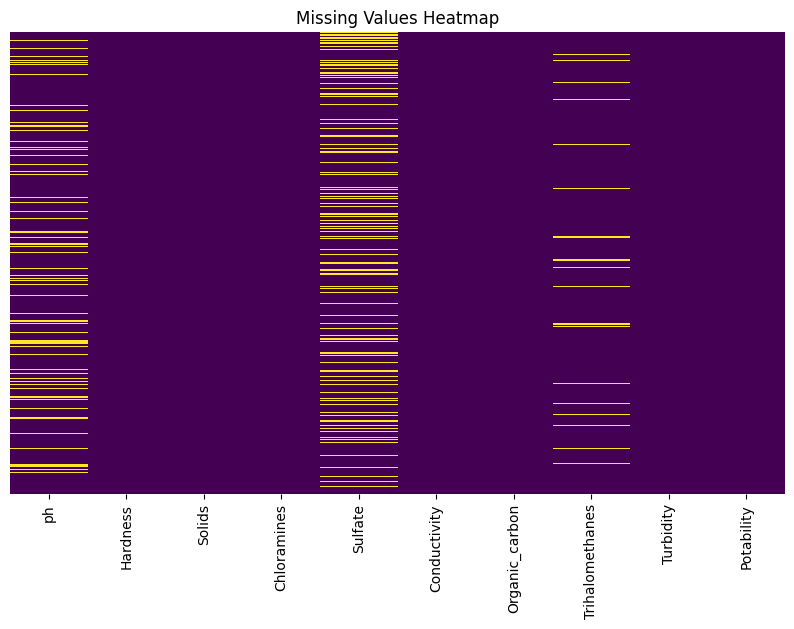

In [8]:
# Lets try to plot missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### Analyze ph column

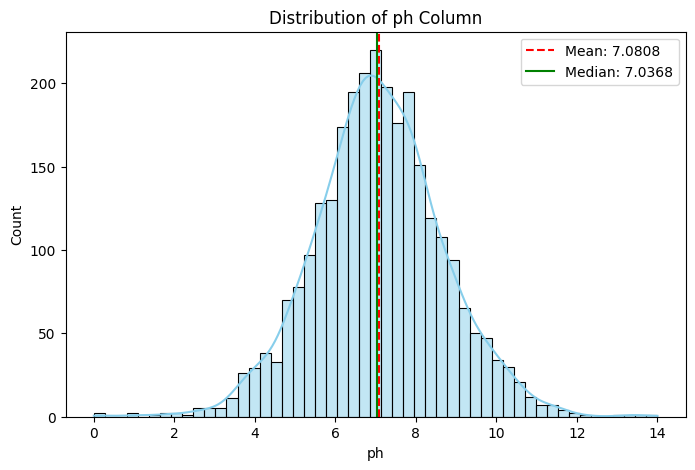

In [9]:
# for ph column set the histogram, mean and median
plt.figure(figsize=(8, 5))
sns.histplot(df['ph'].dropna(), kde=True, color='skyblue')
plt.axvline(df['ph'].mean(), color='red', linestyle='--', label=f"Mean: {df['ph'].mean():.4f}")
plt.axvline(df['ph'].median(), color='green', linestyle='-', label=f"Median: {df['ph'].median():.4f}")
plt.title('Distribution of ph Column')
plt.legend()
plt.show()

Based on the above data, we can impute ph with either mean or median. There is no skewness in the data.

### Analyze Sulfate column

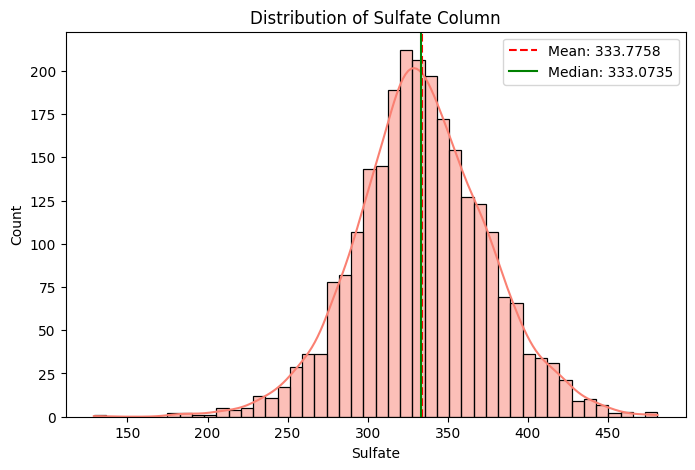

In [10]:
# for Sulfate column set the histogram, mean and median
plt.figure(figsize=(8, 5))
sns.histplot(df['Sulfate'].dropna(), kde=True, color='salmon')
plt.axvline(df['Sulfate'].mean(), color='red', linestyle='--', label=f"Mean: {df['Sulfate'].mean():.4f}")
plt.axvline(df['Sulfate'].median(), color='green', linestyle='-', label=f"Median: {df['Sulfate'].median():.4f}")
plt.title('Distribution of Sulfate Column')
plt.legend()
plt.show()

Based on the above data, we can impute Sulfate with either mean or median.

### Analyze Trihalomethanes column

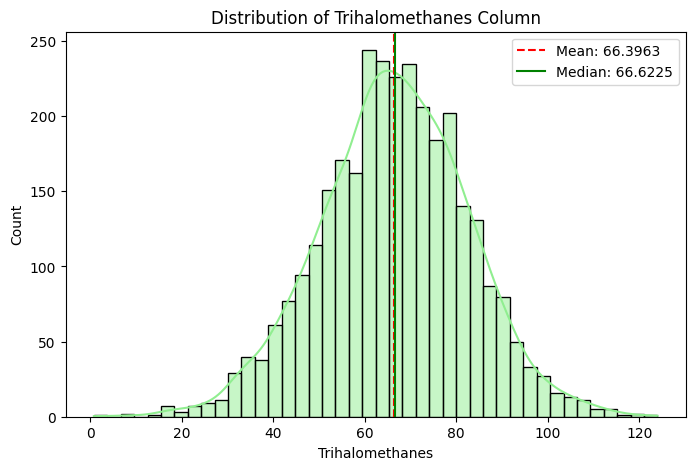

In [11]:
# for Trihalomethanes column set the histogram, mean and median
plt.figure(figsize=(8, 5))
sns.histplot(df['Trihalomethanes'].dropna(), kde=True, color='lightgreen')
plt.axvline(df['Trihalomethanes'].mean(), color='red', linestyle='--', label=f"Mean: {df['Trihalomethanes'].mean():.4f}")
plt.axvline(df['Trihalomethanes'].median(), color='green', linestyle='-', label=f"Median: {df['Trihalomethanes'].median():.4f}")
plt.title('Distribution of Trihalomethanes Column')
plt.legend()
plt.show()

Based on the above data, we can impute Trihalomethanes with either mean or median.

## Missing Value Imputation
### Missing values in ph column

In [12]:
# impute missing values with mean
df['ph'] = df['ph'].fillna(df['ph'].mean())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].mean())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].mean())

## Identify outliers in the data

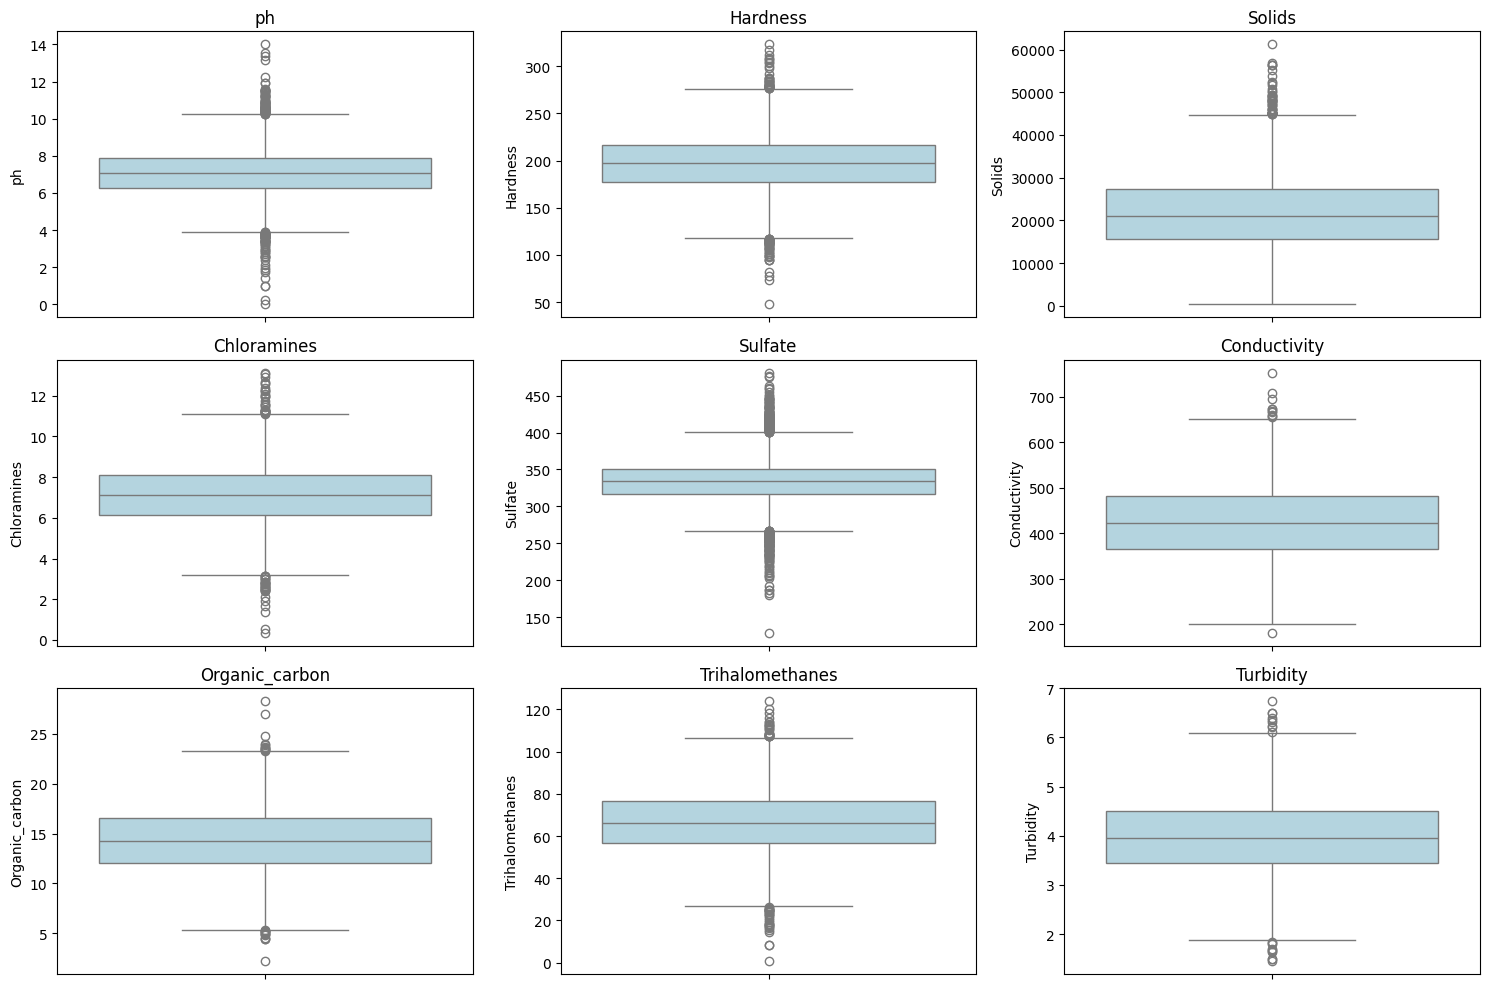

In [13]:
# check outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

## Identify correlation between variables

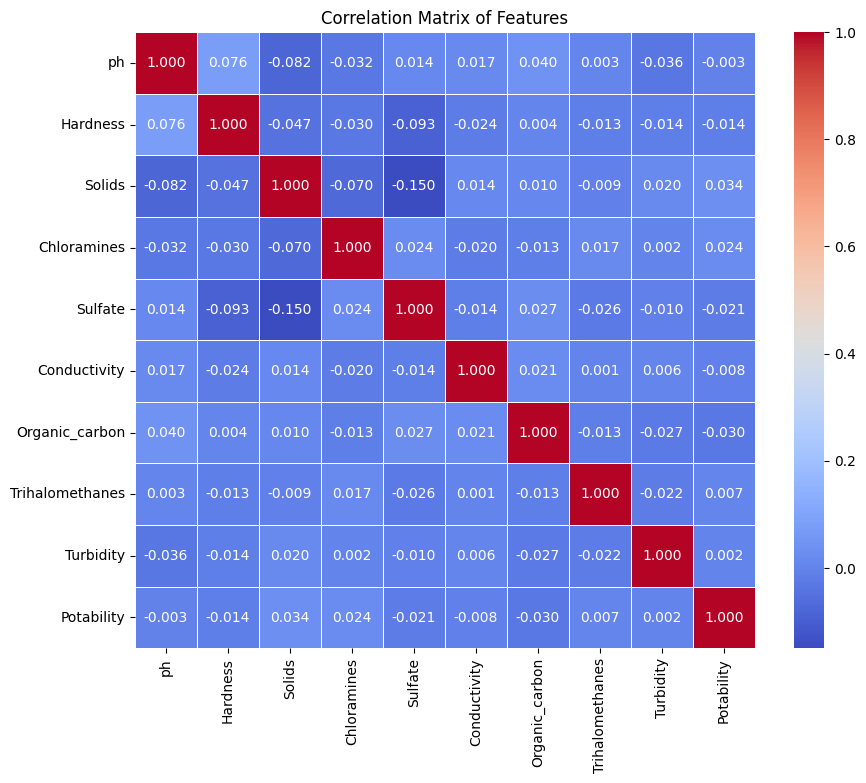

In [14]:
# Check correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

There are no categorical variables in the dataset.

## Identify skewness in the data

In [15]:
# identify skewness
skew_vals = df.skew()
print("Skewness in numerical columns:")
print(skew_vals)

# Showing the skewed columns
skewed_cols = skew_vals[abs(skew_vals) > 1.0]
print(f"Number of skewed columns : {len(skewed_cols)}")

Skewness in numerical columns:
ph                 0.027796
Hardness          -0.039342
Solids             0.621634
Chloramines       -0.012098
Sulfate           -0.041184
Conductivity       0.264490
Organic_carbon     0.025533
Trihalomethanes   -0.085161
Turbidity         -0.007817
Potability         0.450784
dtype: float64
Number of skewed columns : 0


### Skew
There are no skew in our data :)

## Lets see the distribution of Potability

Potability
0    1998
1    1278
Name: count, dtype: int64


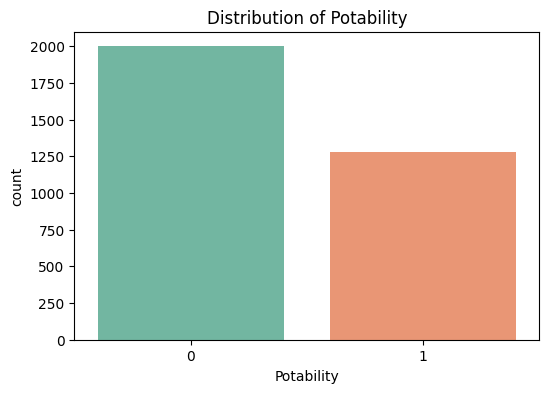

In [16]:
# Value counts of Potability
print(df['Potability'].value_counts())

# Visualization of Potability distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Potability', data=df, palette='Set2')
plt.title('Distribution of Potability')
plt.show()

## Feature Transformation

In [17]:
# print the dataframe head
display(df.head())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [18]:
# Feature transformation
# scale the numeric columns using RobustScaler
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
cols_to_scale = df.columns[:-1]
df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [19]:
# After transformation print the dataframe head
display(df_scaled.head())

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.000000,0.198981,-0.011702,0.085492,1.043542,1.227178,-0.854560,1.028759,-0.935210,0
1,-2.113014,-1.696382,-0.196962,-0.249088,0.000000,1.473406,0.214093,-0.502884,0.514449,0
2,0.639503,0.684850,-0.087287,1.079558,0.000000,-0.028251,0.590024,0.001189,-0.847715,0
3,0.776180,0.437145,0.093483,0.467446,0.694190,-0.505079,0.939076,1.695662,0.635242,0
4,1.263161,-0.398477,-0.252771,-0.293690,-0.710100,-0.202262,-0.592197,-1.718287,0.113188,0


## Save the cleaned data

In [20]:
# Save the scaled and cleaned data to a CSV file
df_scaled.to_csv('water_potability_cleaned.csv', index=False)
print("Cleaned and scaled data saved to 'water_potability_cleaned.csv'!")

Cleaned and scaled data saved to 'water_potability_cleaned.csv'!


## Hypothesis Testing
We define a hypothesis to test in our data set

**Hypothesis 1**:
- **Null**: Increase in pH is associated with increase in Solids
- **Alternate**: No relation between ph and Solids

In [21]:
# Independent t-test on ph and Solids scaled data
t_stat, p_val = stats.ttest_ind(df_scaled['ph'], df_scaled['Solids'])
print(f"Ttest_indResult(statistic={t_stat}, pvalue={p_val})")

Ttest_indResult(statistic=-4.476932191647956, pvalue=7.700634902878753e-06)


the p value is less than 0.05 , so we are rejecting the null hypothesis at 5% significance level.

Next Step in analyzing the data
1. **Xây dựng mô hình (Model Building)**: Huấn luyện các thuật toán phân loại khác nhau như Hồi quy Logistic (Logistic Regression), Cây quyết định (Decision Trees), Rừng ngẫu nhiên (Random Forest), XGBoost, và Máy vectơ hỗ trợ (SVM) để dự đoán thuộc tính mục tiêu `Potability` dựa trên các đặc trưng đã chuẩn hóa.
2. **Xây dựng mô hình quan hệ phi tuyến tính (Non-linear Relationship Modeling)**: Do phân tích tương quan tuyến tính chuẩn cho thấy mối quan hệ giữa các biến cực kỳ yếu (|r| < 0.1), việc sử dụng các phương pháp mô hình hóa phi tuyến tính như các mô hình ensemble dựa trên cây quyết định (Random Forest, LightGBM) hoặc mạng thần kinh (Neural Networks) là cần thiết để phân loại thành công độ an toàn của nước.
3. **Giải quyết sự mất cân bằng lớp (Address Class Imbalance)**: Đảm bảo các mô hình hoạt động tốt bằng cách tối ưu hóa các chỉ số như ROC-AUC, Recall (để giảm thiểu sai số âm tính giả đối với nước không an toàn) và F1-score thay vì chỉ sử dụng độ chính xác thuần túy, do phân phối lớp mục tiêu có sự mất cân bằng nhẹ (39% nước uống được so với 61% không uống được).

Quality of data
- **Giá trị khuyết thiếu (Missing Values)**: Có lượng lớn dữ liệu bị khuyết ở các cột `Sulfate` (~23.8%) và `ph` (~15%), cùng một lượng nhỏ ở cột `Trihalomethanes` (~4.9%). Việc điền các giá trị này bằng giá trị trung bình là một phương pháp cơ sở hiệu quả, mặc dù nó làm giảm nhẹ phương sai tổng thể của dữ liệu.
- **Tính đối xứng phân phối (Distribution Symmetry)**: Tất cả các đặc trưng số đều có độ lệch (skewness) rất thấp (gần bằng 0), nghĩa là phân phối của chúng rất ổn định và có tính đối xứng cao.
- **Xử lý ngoại lệ (Handling Outliers)**: Các giá trị ngoại lệ xuất hiện ở nhiều thông số hóa học (như Solids, Sulfate và Conductivity). Bằng cách sử dụng phương pháp chuẩn hóa `RobustScaler` (chuẩn hóa dựa trên trung vị và khoảng IQR), chúng ta đã chuẩn hóa hiệu quả các tham số số học này và giảm thiểu tối đa tác động tiêu cực của các giá trị ngoại lệ mà không cần loại bỏ các điểm dữ liệu ban đầu.

Key findings
- **Không có sự phụ thuộc tuyến tính đơn giản**: Tương quan tuyến tính giữa các đặc trưng là đặc biệt thấp, với tất cả các hệ số tương quan cặp đều nằm dưới ngưỡng 0.1. Điều này chỉ ra rằng khả năng uống được của nước không phải là một hàm tuyến tính đơn giản của bất kỳ thuộc tính vật lý/hóa học đơn lẻ nào.
- **Hiệu quả của Robust Scaling**: Phương pháp chuẩn hóa Robust đã ánh xạ thành công các cột chịu ảnh hưởng lớn bởi giá trị ngoại lệ vào không gian chuẩn hóa có trung vị bằng 0, đảm bảo chất lượng cao của các cột dữ liệu đã chuẩn hóa phục vụ cho các mô hình phân loại học máy tiếp theo.
- **Bác bỏ giả thuyết Null**: Thông qua kiểm định t-test độc lập, giả thuyết Null cho rằng giá trị pH cao hơn đi kèm với lượng chất rắn hòa tan (Solids) cao hơn đã bị bác bỏ với giá trị p-value cực kỳ có ý nghĩa thống kê khoảng ~7.7e-6. Điều này nhấn mạnh rằng hai tham số này thể hiện các hành vi độc lập với nhau.